<a href="https://colab.research.google.com/github/Leandro2402-bit/Analitica_de_Datos/blob/main/TALLERES/Taller_Discretizacionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Discretización Supervisada utilizando entropia de Shannon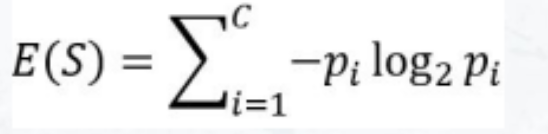

##Objetivo de la discretización
Tomar los datos continuos y categorizarlos en "bins" o "particiones". Dichas particiones deben ser **representativas.**

##Definición de Entropía
Medida de incertidumbre relacionado con la **"pureza"**

### Ejemplo de entropía
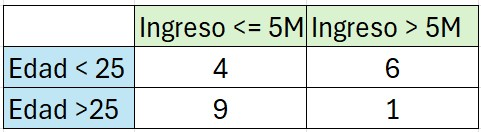


In [ ]:
import numpy as np

# Edad < 25
p_i = 4/10
q_i = 6/10

E_edad_menor_25 = -(p_i * np.log2(p_i) + q_i * np.log2(q_i))
print("La entropia de shanon para edad < 25 es:", E_edad_menor_25)

In [ ]:
p_i = 9/10
q_i = 1/10

E_edad_mayor_25 = -(p_i * np.log2(p_i) + q_i * np.log2(q_i))
print("La entropia de shanon para edad > 25 es:", E_edad_mayor_25)

## Pasos para realizar la discretización utilizando la entropía:

1.   Calcular la entropía de los datos
2.   Para cada potencial partición en los datos:

*   Calcualr la entropía en cada "bin" potencial.
*   Calcular la **entropía de red** para cada partición.
*   Calcular la **ganancia de entropía**

3. Seleccionar la partición mayor **"ganancia de entropía"**

##Formulas utlizadas
$Gain(E_{ew})= E_{initial} - E_{new}$

$Info(D)=\frac{|D_1|}{|D|}*E(D_1) + \frac{{|D_2|}}{|D|}*E(D_2)$

##Ejemplo de discretización usando entropía
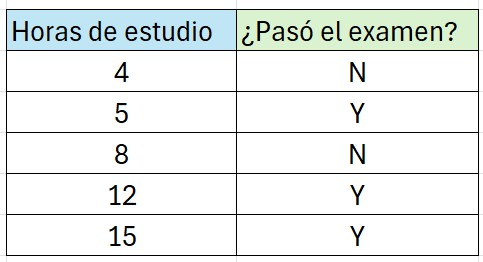



###Paso 1:

In [ ]:
y = 3   #3 que pasan el examen
n = 2   #2 que NO pasan el examnen
T = 5   # Total de estudiantes

p_i = y/T
q_i = n/T

E_initial = -(p_i * np.log2(p_i) + q_i * np.log2(q_i))
print("La entropía inicial es:", E_initial)


##Paso 2

**Las potencial particiones son:**

1.   4.5 horas
2.   6.5 horas
3.   10 horas

In [ ]:
#Funcion calculo de la entropia
def my_entropy(p_i,q_i):
  if p_i == 0:
    term_p_i    = 0
    term_q_i    = q_i*np.log2(q_i)
    val_entropy = -(term_p_i+term_q_i)
  elif q_i == 0:
    term_q_i    = 0
    term_p_i    = p_i*np.log2(p_i)
    val_entropy = -(term_p_i+term_q_i)
  else:
    term_p_i = p_i*np.log2(p_i)
    term_q_i = q_i*np.log2(q_i)
    val_entropy = -(term_p_i+term_q_i)
  return val_entropy

In [ ]:
# Partición < 4.5 horas de estudio

p_i = 0
q_i = 1

E_1 = abs(my_entropy(p_i, q_i))
print("La entropía de la partición 1 (< 4.5 horas) es:", E_1)

In [ ]:
# Partición > 4.5 horas de estudio

p_i = 3/4
q_i = 1/4

E_2 = round(abs(my_entropy(p_i, q_i)), 3)
print("La entropía de la partición 2 (> 4.5) es:", E_2)

##Paso 3

In [ ]:
# Entropia de red con D=5, D1=1, D2=4

def my_entropia_red(D,D1,D2,E_1,E_2):
    val_entropia_red = (abs(D1)/abs(D))*E_1 + (abs(D2)/abs(D))*E_2
    return val_entropia_red


In [ ]:
D=5
D1=1
D2=4

E_red = round(my_entropia_red(D,D1,D2,E_1,E_2), 3)
print("La entropía de la red para 4.5 horas es:", E_red)

In [ ]:
# Ganacia de la entropia
ganancia = round(E_initial - E_red, 3)
print("La ganancia de la entropía para 4.5 horas es:", ganancia)

## Partición de 6.5 horas

In [ ]:
# Partición ≤ 6.5 horas de estudio
# En este grupo hay 3 estudiantes: 1 aprobó, 2 no aprobaron

p_i = 1/3   # proporción que aprueba
q_i = 2/3   # proporción que no aprueba

E_1 = round(abs(my_entropy(p_i, q_i)), 3)
print("La entropía de la partición 1 (≤ 6.5 horas) es:", E_1)


In [ ]:
# Partición > 6.5 horas de estudio
# En este grupo hay 2 estudiantes: 2 aprobaron, 0 reprobaron

p_i = 2/2   # proporción que aprueba
q_i = 0/2   # proporción que no aprueba

E_2 = round(abs(my_entropy(p_i, q_i)), 3)
print("La entropía de la partición 2 (> 6.5 horas) es:", E_2)


In [ ]:
# Entropía de red con D=5, D1=3, D2=2
# D  = total de estudiantes
# D1 = número de estudiantes en el grupo ≤ 6.5 horas
# D2 = número de estudiantes en el grupo > 6.5 horas

def my_entropia_red(D, D1, D2, E_1, E_2):
    val_entropia_red = (abs(D1)/abs(D)) * E_1 + (abs(D2)/abs(D)) * E_2
    return val_entropia_red


In [ ]:
# Cálculo de la entropía de red para la partición en 6.5 horas

D = 5   # total de estudiantes
D1 = 3  # estudiantes con ≤ 6.5 horas
D2 = 2  # estudiantes con > 6.5 horas

E_red = round(my_entropia_red(D, D1, D2, E_1, E_2), 3)
print("La entropía de la red para 6.5 horas es:", E_red)


In [ ]:
# Ganancia de entropía para la partición en 6.5 horas

ganancia = round(E_initial - E_red, 3)
print("La ganancia de la entropía para 6.5 horas es:", ganancia)


##Particion para 10 horas

In [ ]:
# Partición ≤ 10 horas de estudio
# Asumimos: D1 = 4 estudiantes (2 aprueban, 2 no aprueban)

p_i = 2/4   # proporción que aprueba en D1
q_i = 2/4   # proporción que no aprueba en D1

E_1 = round(abs(my_entropy(p_i, q_i)), 3)
print("La entropía de la partición 1 (≤ 10 horas) es:", E_1)


In [ ]:
# Partición > 10 horas de estudio
# Asumimos: D2 = 1 estudiante (1 aprueba, 0 no aprueban)

p_i = 1/1   # proporción que aprueba en D2
q_i = 0/1   # proporción que no aprueba en D2

E_2 = round(abs(my_entropy(p_i, q_i)), 3)
print("La entropía de la partición 2 (> 10 horas) es:", E_2)


In [ ]:
# Cálculo de la entropía de red para la partición en 10 horas
# D  = 5 (total)
# D1 = 4 (≤ 10 horas)
# D2 = 1 (> 10 horas)

D = 5
D1 = 4
D2 = 1

E_red = round(my_entropia_red(D, D1, D2, E_1, E_2), 3)
print("La entropía de la red para 10 horas es:", E_red)


In [ ]:
# Ganancia
ganancia = round(E_initial - E_red, 3)
print("La ganancia de la entropía para 10 horas es: ", ganancia)


##Tabla comparativa en Pandas

In [ ]:
import pandas as pd

# Datos finales de cada partición
data = {
    "Partición (horas)": [4.5, 6.5, 10],
    "Entropía de red (E_red)": [0.649, 0.600, 0.800],
    "Ganancia de entropía (Gain)": [0.322, 0.171, 0.171]
}

# Crear DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar tabla ordenada por ganancia descendente
df_resultados = df_resultados.sort_values(by="Ganancia de entropía (Gain)", ascending=False)

df_resultados.reset_index(drop=True, inplace=True)
df_resultados


##Análisis:
- La partición más eficiente es en 4.5 horas, porque obtiene la mayor ganancia de entropía (0.322).

- La partición en 6.5 horas y la de 10 horas tienen la misma ganancia (0.171), pero la de 6.5 horas muestra menor entropía de red (0.600 vs. 0.800), lo que indica una mejor separación.

- En conclusión: la mejor partición inicial es 4.5 horas, y si hubiera que elegir entre las otras dos, conviene 6.5 horas sobre 10 horas.